46


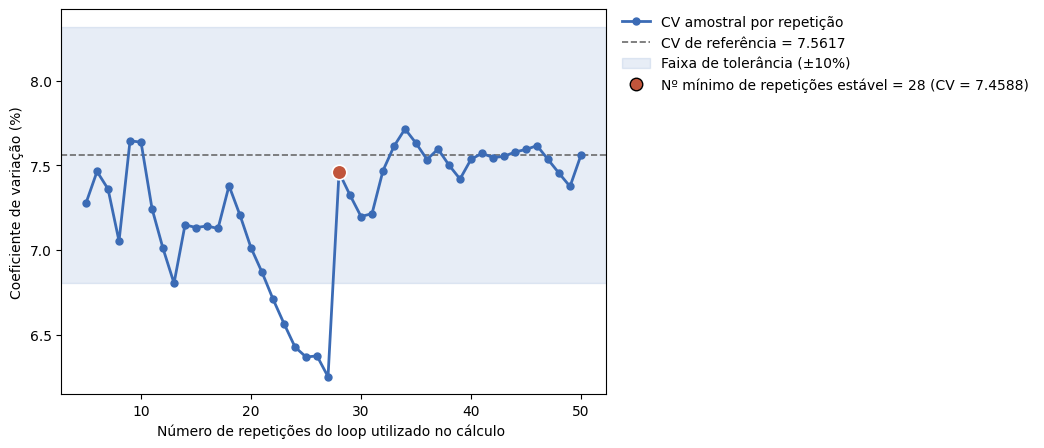

In [258]:
#Defnindo o menor número de amostrar necessário para R

import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import time
import random
import tracemalloc

# example_list = [100, 300, 500, 1000, 1500, 2000, 2500, 3000]

#Calcula o desvio padrão amostral
def calc_cv(workload_time_list: list) -> float:
    #Calcula o desvio padrão amostral
    sample_standart_deviation = np.std(workload_time_list, ddof=1)
    #Calcula a média de todos os tempos de execução gerado até N
    mean = np.mean(workload_time_list)
    cv = (sample_standart_deviation / mean) * 100

    return cv

# 1º - Selecionamos um valor da lista para usarmos na análise
number_of_reps = 1500

# 2º - Criamos uma lista com 1500 valores, com cada valor podendo variar entre 1 e 100.
workload_list = [random.randint(1, 100) for i in range(1500)]

# 3º - Definição da lista que irá armazenar todos os tempos de trabalho.
workload_time_list = []

# 4º - Definição da lista que irá armazenar os coeficientes de variância
workload_execution_cv = []

# Mínimo de repetições nencessárias para começar a calcular os coeficientes de variância 
min_reps = 5

for i in range(1, 50 + 1): 

    inicio = time.perf_counter()

    for i in workload_list:

        for j in range(i):
            x = 1;

    fim = time.perf_counter()

    workload_time_list.append(fim - inicio)

    if len(workload_time_list) >= min_reps:
       workload_execution_cv.append(calc_cv(workload_time_list))


#Pegamos o coeficiente de variância a partir de todos os valores
cv_ref = workload_execution_cv[-1]

#Definições das tolerências máximas e mínimas  
TOL = 0.10
low_ten_percent = cv_ref - (cv_ref * 0.10)
hight_ten_percent = cv_ref + (cv_ref * 0.10)

cv_indexs = list(range(min_reps, len(workload_time_list) + 1))

#Pegamos o índice e o valor do primeiro ponto que cumpre a condição
min_r_index = next(
    (i for i, value in enumerate(workload_execution_cv) if all(hight_ten_percent >= c >= low_ten_percent for c in workload_execution_cv[i:])),
    None
)
min_r_cv = workload_execution_cv[min_r_index] if min_r_index is not None else None
min_r_reps = cv_indexs[min_r_index] if min_r_index is not None else None


AZUL, CINZA, LARANJA = "#3B6BB5", "#6B6B6B", "#C1553B"

fig, ax = plt.subplots(figsize=(11, 5))

print(f"{len(workload_execution_cv)}")

# Desenha/colore uma área entre dois eixos y diferentes
ax.axhspan(low_ten_percent, hight_ten_percent, color=AZUL, alpha=0.12, zorder=0)
# Desenha uma linha em um eixo y específico
ax.axhline(cv_ref, color=CINZA, ls="--", lw=1.2, zorder=1)
# Desenha a reta que cruza os pontos que representa cada uma das amostras 
ax.plot(cv_indexs, workload_execution_cv, color=AZUL, lw=2, marker="o", ms=5, zorder=3)

# Destaca o ponto de estabilização em uma cor diferente
if min_r_index is not None:
    ax.scatter(min_r_reps, min_r_cv, color=LARANJA, s=110, zorder=4, edgecolor="white", linewidth=1.2)

ax.set_xlabel("Número de repetições do loop utilizado no cálculo ")
ax.set_ylabel("Coeficiente de variação (%)")

# Legenda lateral explicando cada elemento pela cor
legend_handles = [
    Line2D([0], [0], color=AZUL, lw=2, marker="o", ms=5, label="CV amostral por repetição"),
    Line2D([0], [0], color=CINZA, ls="--", lw=1.2, label=f"CV de referência = {cv_ref:.4f}"),
    Patch(color=AZUL, alpha=0.12, label="Faixa de tolerância (±10%)"),
]
if min_r_index is not None:
    legend_handles.append(
        Line2D([0], [0], marker="o", color="none", markerfacecolor=LARANJA, markersize=9,
               label=f"Nº mínimo de repetições estável = {min_r_reps} (CV = {min_r_cv:.4f})")
    )

ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=False)
fig.subplots_adjust(right=0.62)


In [259]:
# Coleta dos R tempos de execução para cada tamanho de carga de trabalho (n)

R = 40
example_list = [100, 300, 500, 1000, 1500, 2000, 2500, 3000]

execution_times_by_n = {}

for n in example_list:
    times_for_n = []
    for r in range(R):
        current_workload = [random.randint(1, 100) for _ in range(n)]

        inicio = time.perf_counter()
        for i in current_workload:
            for j in range(i):
                x = 1
        fim = time.perf_counter()

        times_for_n.append(fim - inicio)

    execution_times_by_n[n] = times_for_n
    print(f"n={n}: {R} repetições concluídas")

# Paleta de cores consistente para o mesmo n em todos os gráficos seguintes
n_colors = {n: color for n, color in zip(example_list, plt.cm.tab10(np.linspace(0, 1, len(example_list))))}


n=100: 40 repetições concluídas
n=300: 40 repetições concluídas
n=500: 40 repetições concluídas
n=1000: 40 repetições concluídas
n=1500: 40 repetições concluídas
n=2000: 40 repetições concluídas
n=2500: 40 repetições concluídas
n=3000: 40 repetições concluídas


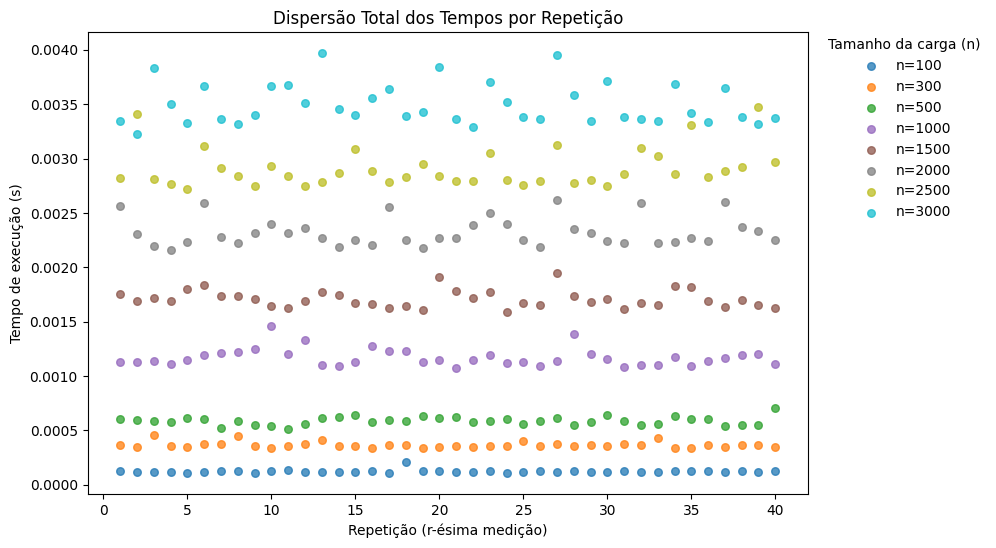

In [260]:
# 1) Scatter Plot — Dispersão Total
# Mostra todos os R tempos medidos para cada n, ao longo das repetições.
# Serve para identificar outliers e tendências de aumento ao longo das repetições
# (sinal de throttling térmico).

fig, ax = plt.subplots(figsize=(11, 6))

reps = range(1, R + 1)
for n in example_list:
    ax.scatter(reps, execution_times_by_n[n], color=n_colors[n], label=f"n={n}", alpha=0.75, s=30)

ax.set_xlabel("Repetição (r-ésima medição)")
ax.set_ylabel("Tempo de execução (s)")
ax.set_title("Dispersão Total dos Tempos por Repetição")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=False, title="Tamanho da carga (n)")
fig.subplots_adjust(right=0.78)
plt.show()


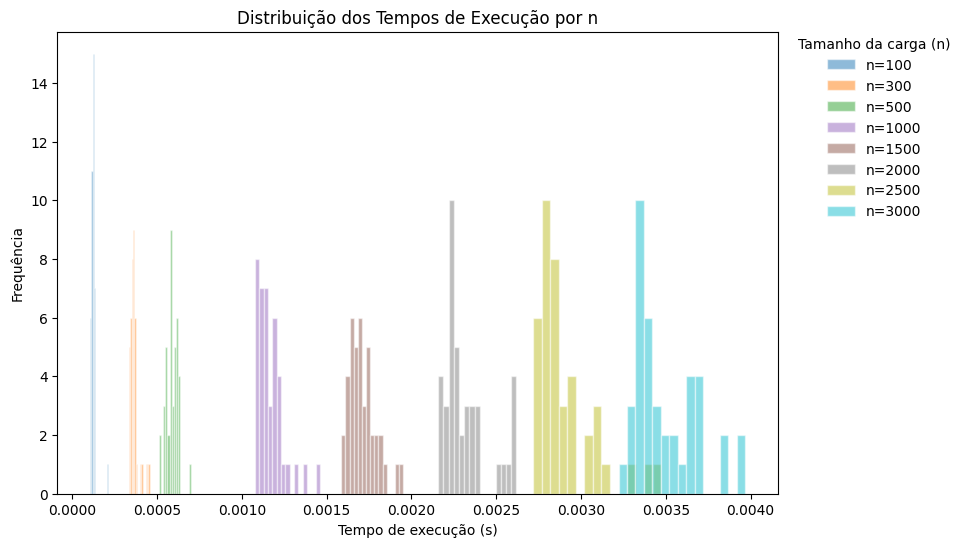

In [261]:
# 2) Histogramas Sobrepostos — Distribuição
# Mostra a densidade de frequência dos tempos para cada n.
# Espera-se "sinos" estreitos e bem separados; muita sobreposição entre
# n diferentes indica instabilidade.

fig, ax = plt.subplots(figsize=(11, 6))

for n in example_list:
    ax.hist(execution_times_by_n[n], bins=15, alpha=0.5, color=n_colors[n], label=f"n={n}", edgecolor="white")

ax.set_xlabel("Tempo de execução (s)")
ax.set_ylabel("Frequência")
ax.set_title("Distribuição dos Tempos de Execução por n")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=False, title="Tamanho da carga (n)")
fig.subplots_adjust(right=0.78)
plt.show()


Média dos tempos de 2000 0.002908108226256445
Coeficiente de variância das execuções de 2000 6.153237280670786


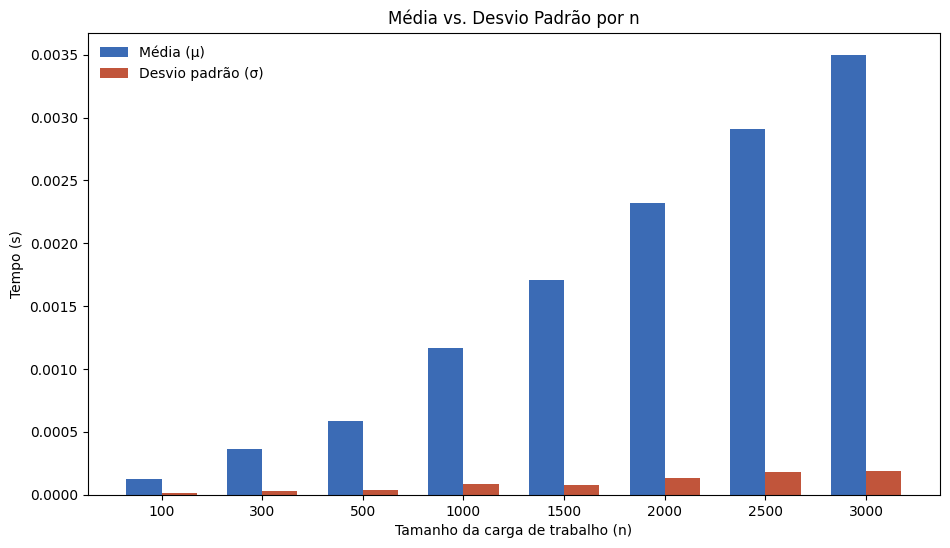

In [ ]:
# 3) Barras: Média vs. Desvio Padrão
# Comparação direta entre a média (μ, sinal) e o desvio padrão (σ, ruído)
# para cada n. A barra de σ deve ser visivelmente menor que a de μ.

means = [np.mean(execution_times_by_n[n]) for n in example_list]
stds = [np.std(execution_times_by_n[n], ddof=1) for n in example_list]

print(f"Média dos tempos de 2000 {means[6]}")
print(f"Coeficiente de variância das execuções de 2000 {(stds[6] / means[6]) * 100}")

x = np.arange(len(example_list))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width/2, means, width, color=AZUL, label="Média (μ)")
ax.bar(x + width/2, stds, width, color=LARANJA, label="Desvio padrão (σ)")

ax.set_xticks(x)
ax.set_xticklabels([str(n) for n in example_list])
ax.set_xlabel("Tamanho da carga de trabalho (n)")
ax.set_ylabel("Tempo (s)")
ax.set_title("Média vs. Desvio Padrão por n")
ax.legend(frameon=False)
plt.show()


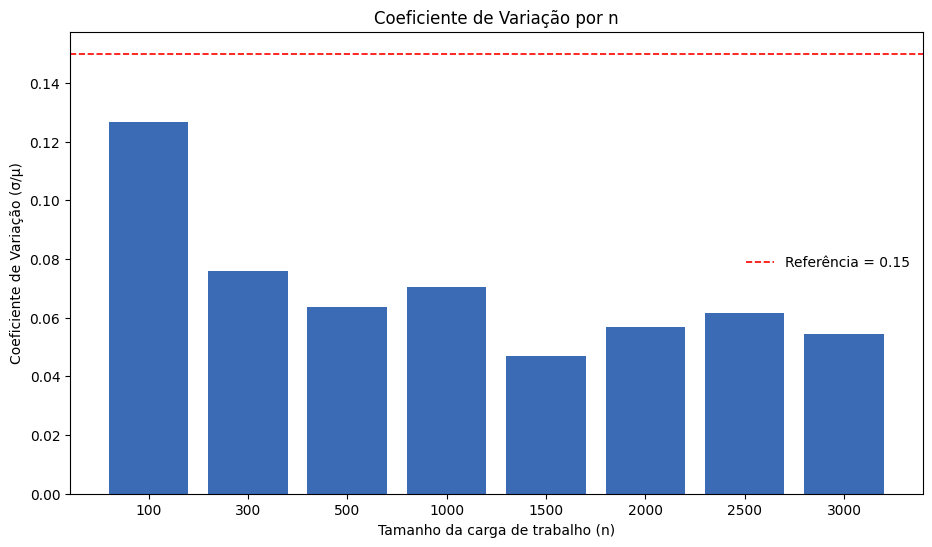

In [263]:
# 4) Barras: Coeficiente de Variação
# Mostra o valor exato de C = σ/μ para cada n. Uma linha vermelha em 0,15
# serve de referência — todas as barras devem estar abaixo dela.

cv_by_n = [stds[i] / means[i] for i in range(len(example_list))]

REF_CV = 0.15
bar_colors = [AZUL if cv <= REF_CV else LARANJA for cv in cv_by_n]

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar([str(n) for n in example_list], cv_by_n, color=bar_colors)
ax.axhline(REF_CV, color="red", ls="--", lw=1.2, label=f"Referência = {REF_CV}")

ax.set_xlabel("Tamanho da carga de trabalho (n)")
ax.set_ylabel("Coeficiente de Variação (σ/μ)")
ax.set_title("Coeficiente de Variação por n")
ax.legend(frameon=False)
plt.show()
